## Simulation of the moving source

1. Get the source excitation from the provided FDM simulation data.
2. Create the rail mesh of monopoles
3. Simulate using both frequency domain and time domain methods
4. Compare the results with the older simulation results
5. Auralize the time domain results

In [1]:
import numpy as np

from frequency_domain import monopole_multi_fa__calcf__outf



### Step 1
Get the source excitation from the provided FDM simulation data.

In [2]:
u_y = np.load('provided_data/u_y_reduced.npy').astype(np.float16)
u_z = np.load('provided_data/u_z_reduced.npy').astype(np.float16)
phi_x = np.load('provided_data/phi_x_reduced.npy').astype(np.float16)

print(u_y.shape)

(45563, 2586)


### Step 2
Create the rail mesh of monopoles

In [3]:
from rolland.database.rail.db_rail import UIC60
from utils import interpolate_contour_2d, create_mesh, calculate_projected_area, calculate_centre_and_area_triangles, \
    vector_deflection_total

rail_geometry = UIC60.rl_geo
length = 5
rail_geometry = interpolate_contour_2d(rail_geometry, 25)
triangle_coords, triangle_index = create_mesh(rail_geometry,
                                              mesh_size=0.05,
                                              L=length  #146.0
                                              )

A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)
print(f'mean area = {A.mean()}')
projected_area = calculate_projected_area(A, norm, 1)

dx = 0.05
dt = (0.5e-5) * 8

excitation_point = 65
cut_start_m = excitation_point - length / 2

n_x_cut = int(round(length / dx)) + 1
start_index = int(round(cut_start_m / dx))
end_index = start_index + n_x_cut

centre_sim = centre.copy()
centre_sim[:, 2] = centre_sim[:, 2] + cut_start_m

print(f'excitation point = {excitation_point} '
      f'cut_start_m = {cut_start_m} '
      f'start_index = {start_index} '
      f'end_index = {end_index} '
      f'n_x_cut = {n_x_cut}')

print(u_y.shape)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 20%] Meshing curve 9 (Line)
Info    : [ 20%] Meshing curve 10 (Line)
Info    : [ 20%] Meshing curve 11 (Line)
Info    : [ 20%] Meshing curve 12 (Line)
Info    : [ 20%] Meshing curve 13 (Line)
Info    : [ 20%] Meshing curve 14 (Line)
Info    : [ 20%] Meshing curve 15 (Line)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 30%] Meshing curve 18 (Line)
Info    : [ 30%] Meshing curve 19 (Line)
Info    : [ 30%] Meshing curve 20 (Line)
Info    : [ 30%] Meshing curve 21 (Line)
Info    : [ 30%] Meshing curve 22 (Line)
Info    : [ 30%] Meshing curve 23 (Line)
Info    : [ 40%] Meshing curve 24 (Line)
I

### Step 3
Simulate using both frequency domain and time domain methods

In [4]:
u_y = u_y[:, start_index:end_index]
u_z = u_z[:, start_index:end_index]
phi_x = phi_x[:, start_index:end_index]


import scipy as sp

f_axis_sim = sp.fft.fftfreq(u_y.shape[0], dt)
f_min = 0
f_max = 3000
frequency_mask = (f_axis_sim >= f_min) & (f_axis_sim <= f_max)

omega = 2 * np.pi * f_axis_sim[frequency_mask]



v_y = sp.fft.fft(u_y, norm='forward', axis=0) * 2
v_y = (1j * omega[:, None]) * v_y[frequency_mask, :]

v_z = sp.fft.fft(u_z, norm='forward', axis=0) * 2
v_z = (1j * omega[:, None]) * v_z[frequency_mask, :]

phi_x_fd = sp.fft.fft(phi_x, norm='forward', axis=0) * 2
phi_x_fd = (1j * omega[:, None]) * phi_x_fd[frequency_mask, :]

nx = u_y.shape[1]
x_axis = np.arange(nx) * dx + (start_index * dx)
print(x_axis.shape)
print(f'nx: {nx} '
      f'dx: {dx} '
      f'starting_point: {start_index * 0.05}')


triangle_v_y, triangle_v_z = vector_deflection_total(
    v_y,
    v_z,
    phi_x_fd,
    centre
)

y_projected_area = calculate_projected_area(A, norm, 0)
z_projected_area = calculate_projected_area(A, norm, 1)

print(u_y.shape)


(101,)
nx: 101 dx: 0.05 starting_point: 62.5
(45563, 101)


Step 3.1
Simulate using the frequency domain method

In [5]:
from utils import run_simulation_semi_circle_total
semi_circle_centre = np.array((-0.71, -0.08, excitation_point))
P_total, P_z, P_y = run_simulation_semi_circle_total(
    circle_centre=semi_circle_centre,
    circle_radius=2.5,
    number_of_points=5,
    simulation_function=monopole_multi_fa__calcf__outf,
    V_z=triangle_v_z.T,
    A_z=z_projected_area[:, None],
    V_y=triangle_v_y.T,
    A_y=y_projected_area[:, None],
    return_components=True,
    freqs=f_axis_sim[frequency_mask],
    X=centre_sim,
)

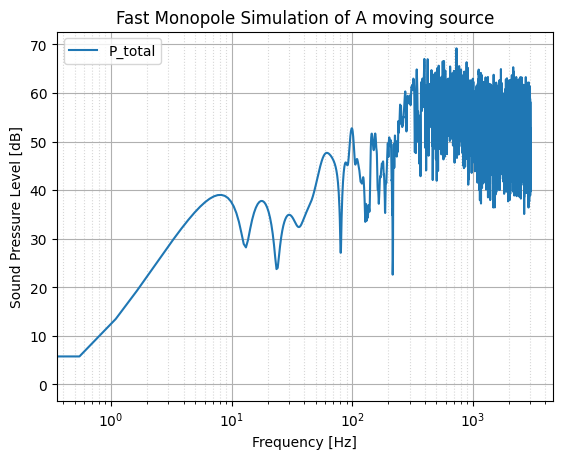

In [6]:
from matplotlib import pyplot as plt
import numpy as np

p0 = 2e-5

P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)
P_z_db = 20 * np.log10((np.abs(P_z) + p0) / p0)
P_y_db = 20 * np.log10((np.abs(P_y) + p0) / p0)

f_plot = f_axis_sim[frequency_mask]
plt_mask = (f_plot >= f_min) & (f_plot <= f_max)

plt_f_axis = f_plot[plt_mask]
plt_P_total_db = P_total_db[plt_mask]
plt_P_z_db = P_z_db[plt_mask]
plt_P_y_db = P_y_db[plt_mask]

plt.plot(plt_f_axis, plt_P_total_db, label="P_total")
#plt.plot(plt_f_axis, plt_P_z_db, label="P_z")
#plt.plot(plt_f_axis, plt_P_y_db, label="P_y")
#plt.plot(wagner_simulation_data[:, 0], wagner_simulation_data[:, 1], label="FEM Simulation")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Sound Pressure Level [dB]')
plt.legend()
plt.xscale('log')
plt.grid(True, which='major')
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.title('Fast Monopole Simulation of A moving source')
plt.show()

Step 3.2
Simulate using the time domain method

(45563, 101)
4e-05


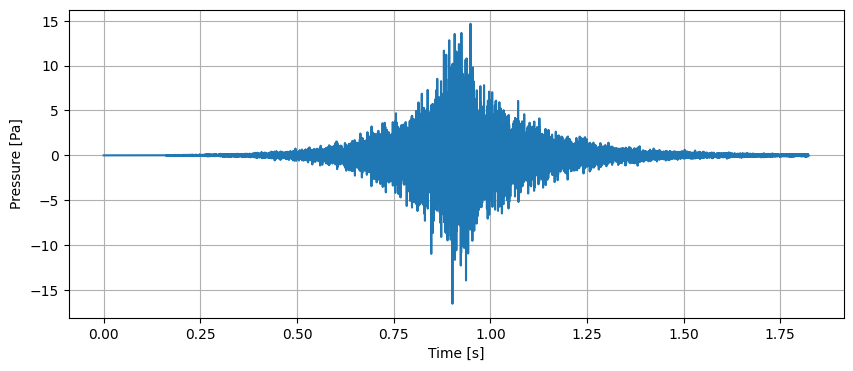

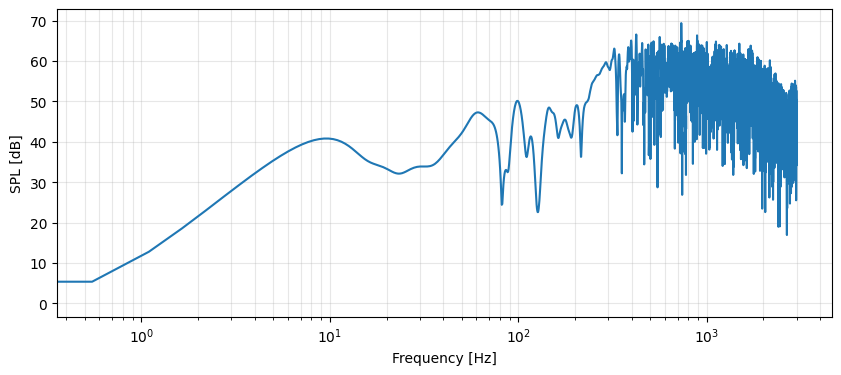

In [7]:
from utils import run_simulation_semi_circle_total
from time_domain import monopole_multi_ta__calct__outf
v_y_td = np.gradient(u_y, dt, axis=0)
v_z_td = np.gradient(u_z, dt, axis=0)
phi_x_td = np.gradient(phi_x, dt, axis=0)

print(v_y_td.shape)
print(dt)

triangle_v_y_td, triangle_v_z_td = vector_deflection_total(
    v_y_td, v_z_td, phi_x_td, centre
)

# Statt run_simulation_semi_circle_total zu verwenden:
p_z = monopole_multi_ta__calct__outf(
    V_td=triangle_v_z_td.T,
    X=centre_sim,
    y=semi_circle_centre,  # einen fixen Punkt
    dt=dt,
    A=z_projected_area[:, None],
)

# Nach dem FFT-Block:
t = np.arange(len(p_z)) * dt
f = np.fft.rfftfreq(len(p_z), d=dt)
Pf = np.fft.rfft(p_z, norm="forward")
L = 20*np.log10((np.abs(Pf)+2e-5)/(2e-5))

# Plot 1: Zeit
plt.figure(figsize=(10,4))
plt.plot(t, p_z.real)
plt.xlabel("Time [s]"); plt.ylabel("Pressure [Pa]")
plt.grid()
plt.show()

# Plot 2: Frequenz gefiltert
mask = (f >= f_min) & (f <= f_max)
plt.figure(figsize=(10,4))
plt.plot(f[mask], L[mask])
plt.xscale("log")
plt.xlabel("Frequency [Hz]"); plt.ylabel("SPL [dB]")
plt.grid(which="both", alpha=0.3)
plt.show()



In [8]:
dt*v_y_td.shape[0]

1.8225200000000001

In [9]:
# from scipy.io import wavfile
#
# # Normalisieren auf int16 Bereich
# p_z_normalized = p_z.real / np.max(np.abs(p_z.real))
# p_z_int16 = (p_z_normalized * 32767).astype(np.int16)
#
# # Sampling rate
# fs = int(1 / dt)
#
# # Speichern
# wavfile.write("time_domain_simulation.wav", fs, p_z_int16)
p_time = p_z.real
p_time = p_time / np.max(np.abs(p_time))
samplerate = int(1 / dt)

sp.io.wavfile.write("time_domain_simulation_2.wav", samplerate, p_time.astype(np.float32))
